In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/student_data.csv")
# tell us about the data types and non-null counts
# df.info() 

# mean, std, min, max, 25%, 50%, 75%
df.describe() 

# show the first 5 rows of the data
df.head()
# df.isnull().sum() // check for missing values in each column

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


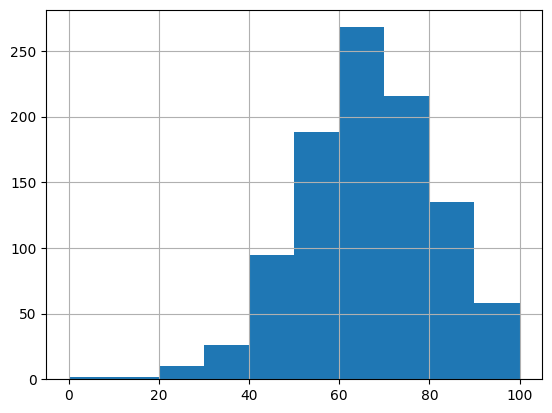

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/student_data.csv")

df["gender"].value_counts()
df["parental level of education"].value_counts()
df.groupby("gender")[["math score"]].mean()
df["math score"].hist()
plt.show()

MAE: 4.21476314247485
MSE: 29.095169866715487
R2 Score: 0.8804332983749565


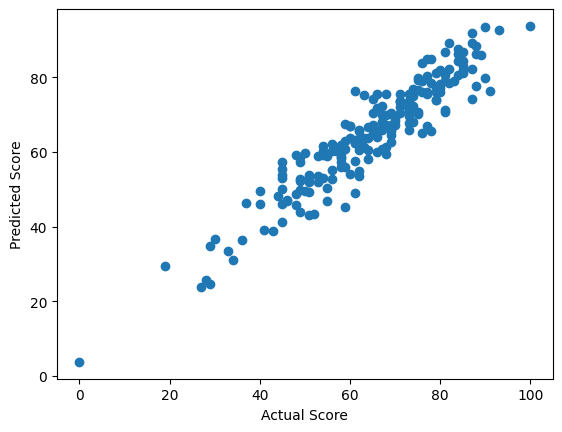

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/student_data.csv")

X = df.drop("math score", axis=1)
y = df["math score"]

# y.head()
X = pd.get_dummies(X, drop_first=True)
X.head()

# X.info()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape
X_test.shape

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
predictions[:10]

comparison = pd.DataFrame({
  "Actual": y_test, 
  "Predicted": predictions})

comparison.head(10)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)

mse = mean_squared_error(y_test, predictions)

print("MSE:", mse)

r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

plt.scatter(y_test, predictions)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.show()